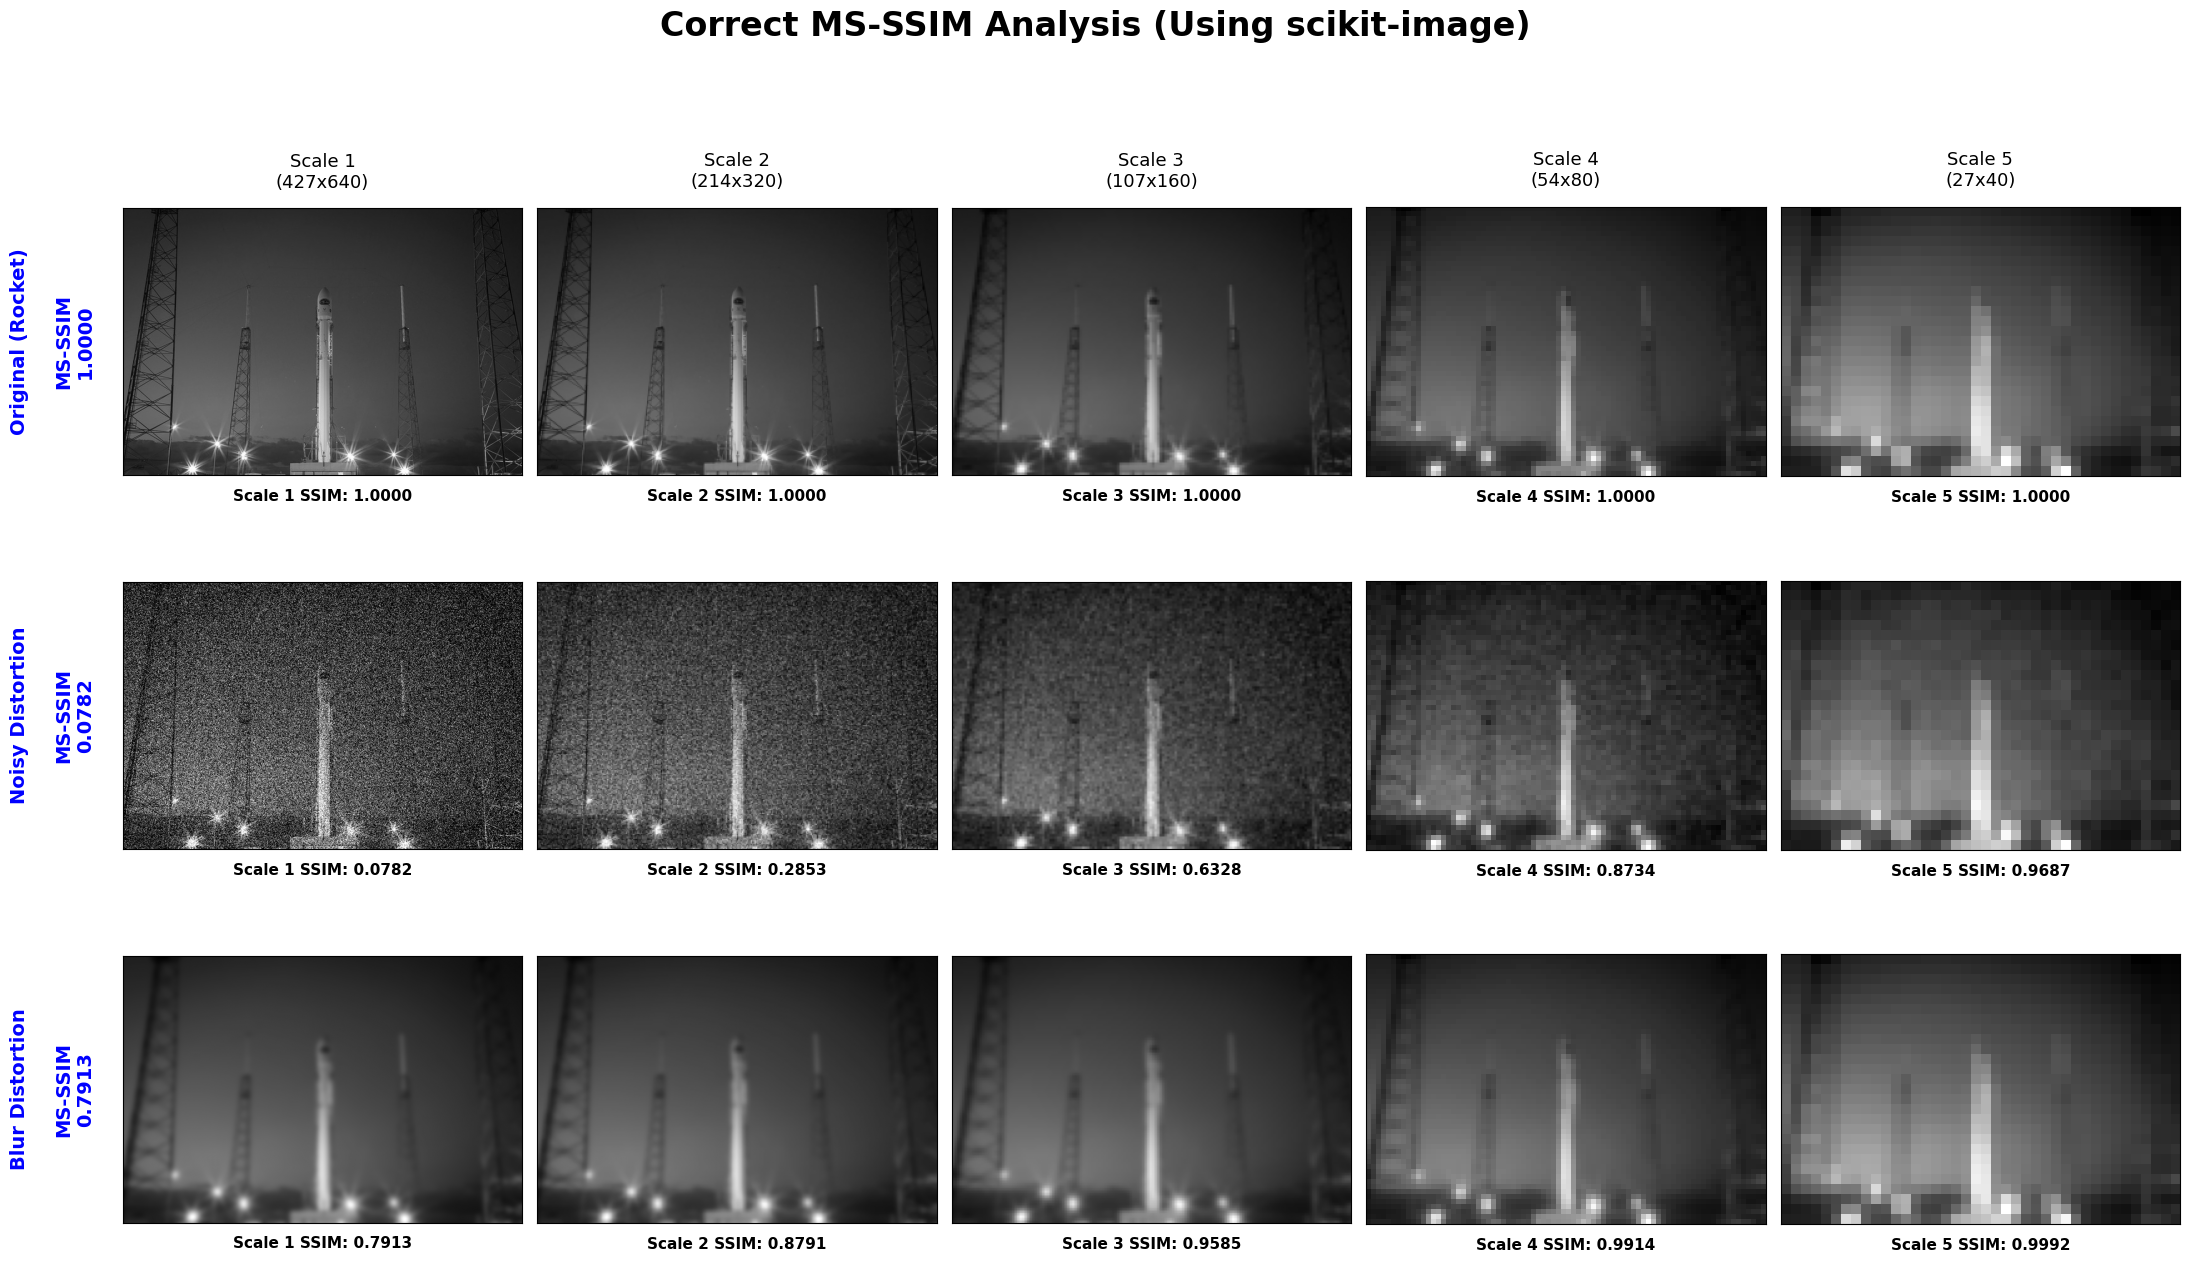

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.transform import pyramid_gaussian
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.metrics import structural_similarity

# 1. Prepare Images
original_color = img_as_float(data.rocket())
original = np.mean(original_color, axis=2) 

noisy = random_noise(original, mode='gaussian', var=0.05, clip=True)
blurred = gaussian(original, sigma=4)

# 2. 올바른 MS-SSIM 계산 함수 (scikit-image 사용)
def get_correct_ms_ssim(org, dist):
    # 피라미드 생성 (시각화용)
    org_pyramid = list(pyramid_gaussian(org, max_layer=4, downscale=2, channel_axis=None))
    dist_pyramid = list(pyramid_gaussian(dist, max_layer=4, downscale=2, channel_axis=None))
    
    scale_scores = []
    for o, d in zip(org_pyramid, dist_pyramid):
        # 각 스케일별 SSIM (시각화용)
        score = structural_similarity(o, d, data_range=1.0)
        scale_scores.append(score)
        
    # 올바른 MS-SSIM: scikit-image의 multiscale=True 사용
    final_ms_ssim = structural_similarity(org, dist, multiscale=True, data_range=1.0)
    
    return dist_pyramid, scale_scores, final_ms_ssim

# Run analysis
noisy_pyramid, noisy_scales, ms_ssim_noisy = get_correct_ms_ssim(original, noisy)
blurred_pyramid, blurred_scales, ms_ssim_blurred = get_correct_ms_ssim(original, blurred)

# 3. Visualization
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
titles = ["Original (Rocket)", "Noisy Distortion", "Blur Distortion"]
pyramids = [list(pyramid_gaussian(original, max_layer=4, channel_axis=None)), noisy_pyramid, blurred_pyramid]
scale_scores_list = [[1.0]*5, noisy_scales, blurred_scales]
final_ms_scores = [1.0, ms_ssim_noisy, ms_ssim_blurred]

for row in range(3):
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(pyramids[row][col], cmap='gray')
        
        score_text = f"Scale {col+1} SSIM: {scale_scores_list[row][col]:.4f}"
        ax.set_xlabel(score_text, fontsize=11, fontweight='bold', labelpad=10)
        
        if col == 0:
            row_label = f"{titles[row]}\n\nMS-SSIM\n{final_ms_scores[row]:.4f}"
            ax.set_ylabel(row_label, fontsize=14, fontweight='extra bold', color='blue', labelpad=20)
        
        if row == 0:
            ax.set_title(f'Scale {col+1}\n({pyramids[row][col].shape[0]}x{pyramids[row][col].shape[1]})', fontsize=13, pad=15)
            
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Correct MS-SSIM Analysis (Using scikit-image)', fontsize=24, y=1.08, fontweight='bold')
plt.show()

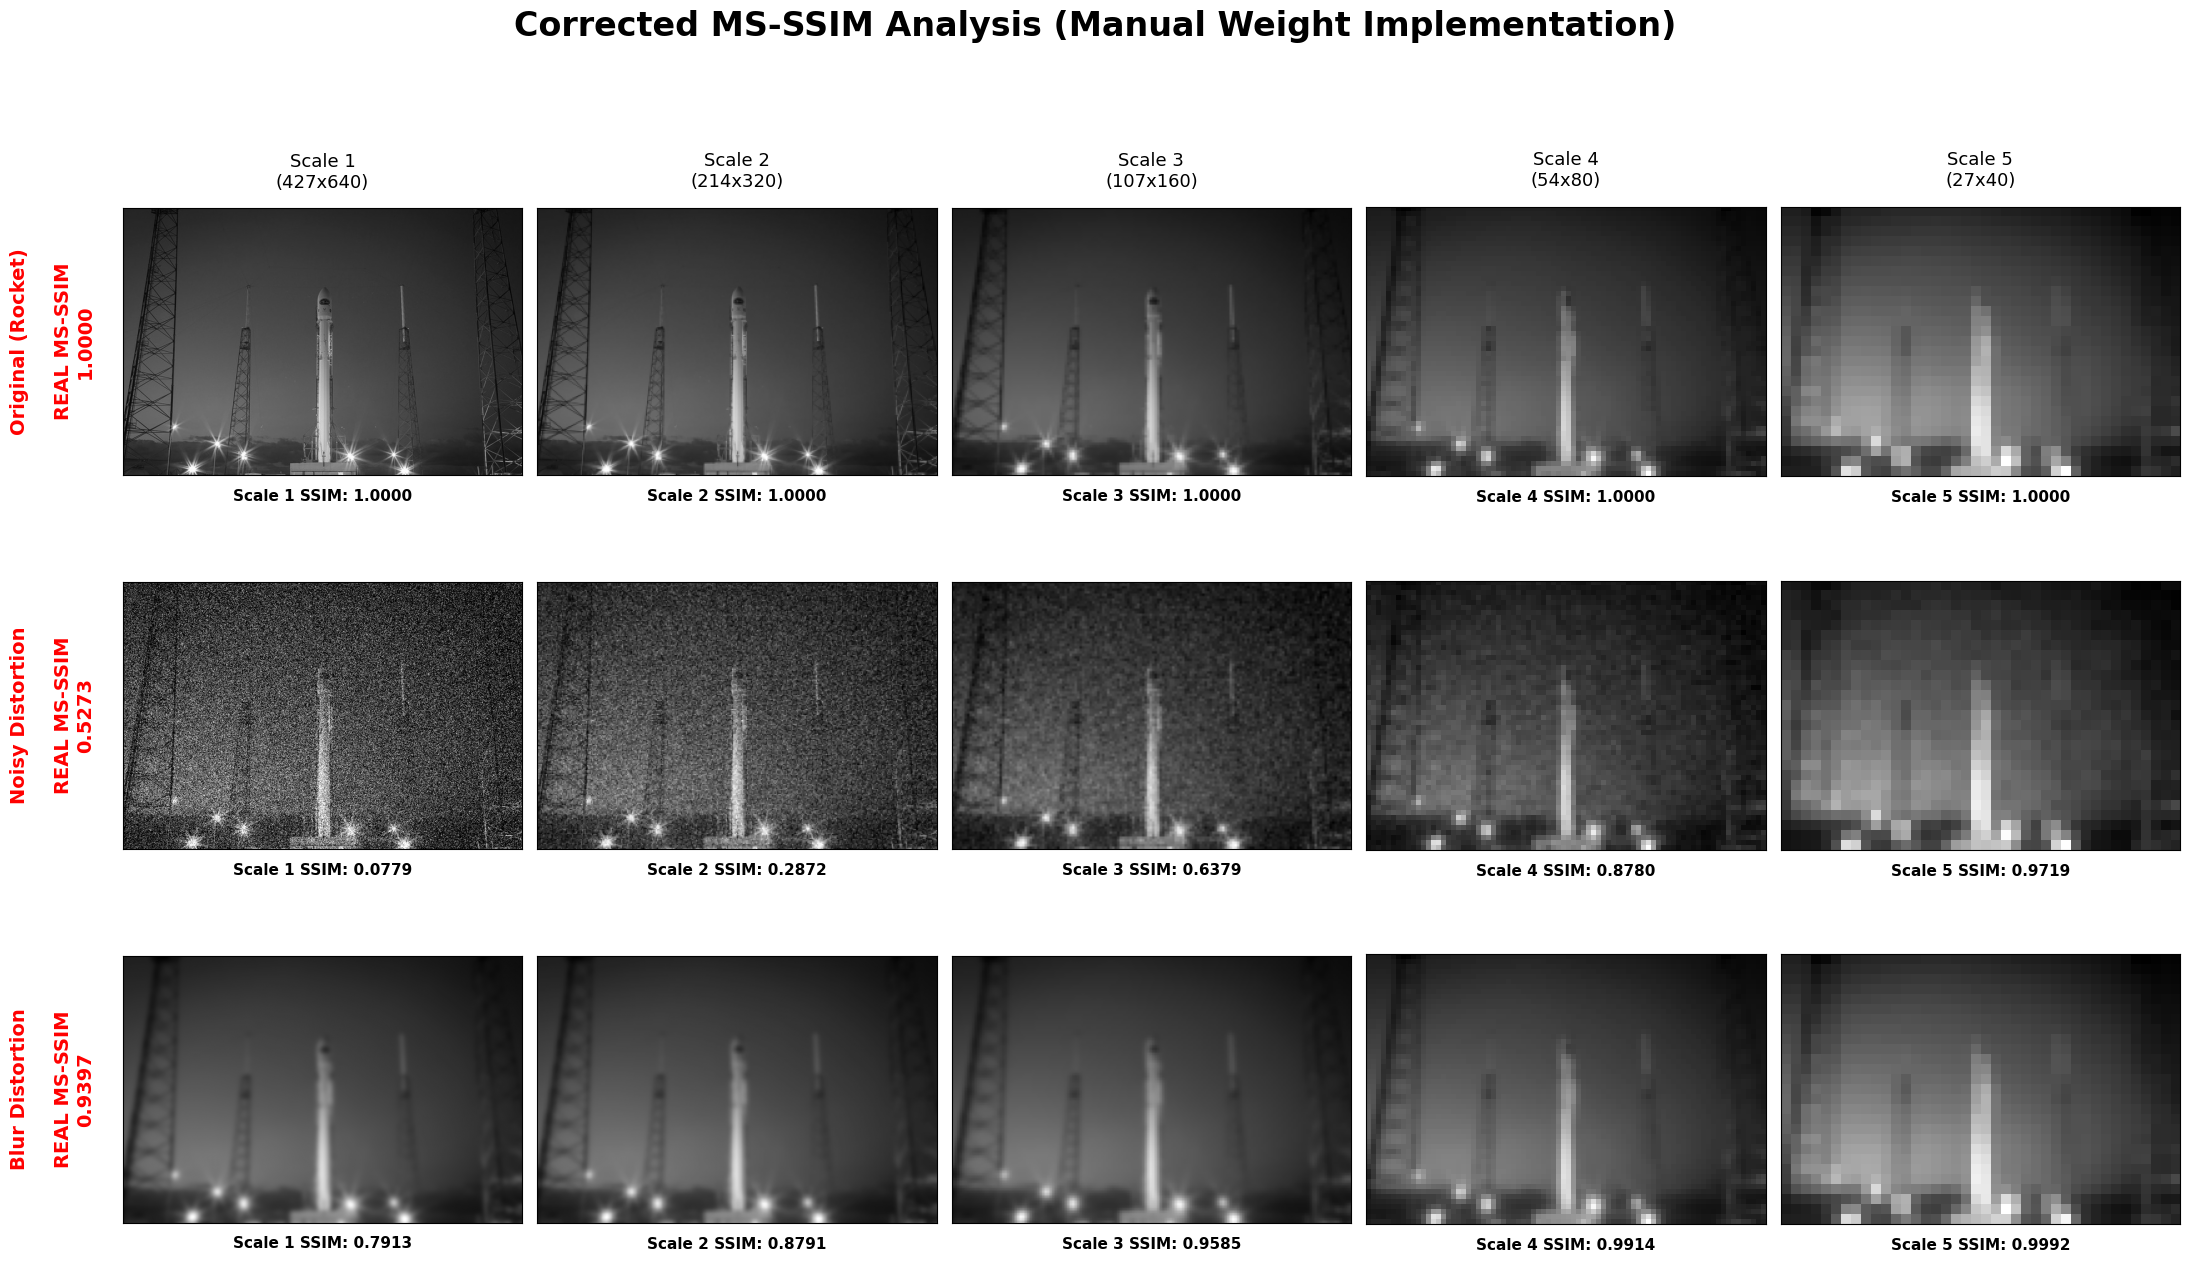

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.transform import pyramid_gaussian
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.metrics import structural_similarity

# 1. Prepare Images
original_color = img_as_float(data.rocket())
original = np.mean(original_color, axis=2) 

noisy = random_noise(original, mode='gaussian', var=0.05, clip=True)
blurred = gaussian(original, sigma=4)

# 2. Function to calculate REAL MS-SSIM (논문 공식 직접 구현)
def get_real_ms_ssim(org, dist):
    # 피라미드 생성 (Scale 1 ~ 5)
    org_pyramid = list(pyramid_gaussian(org, max_layer=4, downscale=2, channel_axis=None))
    dist_pyramid = list(pyramid_gaussian(dist, max_layer=4, downscale=2, channel_axis=None))
    
    scale_scores = []
    for o, d in zip(org_pyramid, dist_pyramid):
        # 각 스케일별 기본 SSIM 계산
        score = structural_similarity(o, d, data_range=1.0)
        scale_scores.append(score)
        
    # ==========================================
    # [핵심 수정] 가짜 옵션 삭제, 논문 공식 직접 적용
    # ==========================================
    weights = np.array([0.0448, 0.2856, 0.3001, 0.2363, 0.1333])
    
    # SSIM 점수가 음수일 경우 승수 계산 에러가 나므로 0으로 하한선 설정
    safe_scores = np.maximum(scale_scores, 0)
    
    # MS-SSIM 공식 근사치: 각 스케일 점수의 (가중치)제곱을 모두 곱함
    # Π (score_j ^ weight_j)
    final_ms_ssim = np.prod(np.power(safe_scores, weights))
    
    return dist_pyramid, scale_scores, final_ms_ssim

# Run analysis
noisy_pyramid, noisy_scales, ms_ssim_noisy = get_real_ms_ssim(original, noisy)
blurred_pyramid, blurred_scales, ms_ssim_blurred = get_real_ms_ssim(original, blurred)

# 3. Visualization
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
titles = ["Original (Rocket)", "Noisy Distortion", "Blur Distortion"]
pyramids = [list(pyramid_gaussian(original, max_layer=4, channel_axis=None)), noisy_pyramid, blurred_pyramid]
scale_scores_list = [[1.0]*5, noisy_scales, blurred_scales]
final_ms_scores = [1.0, ms_ssim_noisy, ms_ssim_blurred]

for row in range(3):
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(pyramids[row][col], cmap='gray')
        
        score_text = f"Scale {col+1} SSIM: {scale_scores_list[row][col]:.4f}"
        ax.set_xlabel(score_text, fontsize=11, fontweight='bold', labelpad=10)
        
        if col == 0:
            # 드디어 Scale 1과 다른 '진짜' 합산 점수가 출력됩니다!
            row_label = f"{titles[row]}\n\nREAL MS-SSIM\n{final_ms_scores[row]:.4f}"
            ax.set_ylabel(row_label, fontsize=14, fontweight='extra bold', color='red', labelpad=20)
        
        if row == 0:
            ax.set_title(f'Scale {col+1}\n({pyramids[row][col].shape[0]}x{pyramids[row][col].shape[1]})', fontsize=13, pad=15)
            
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Corrected MS-SSIM Analysis (Manual Weight Implementation)', fontsize=24, y=1.08, fontweight='bold')
plt.show()

In [27]:
# MS-SSIM 확인
from skimage.metrics import structural_similarity
ms_ssim = structural_similarity(original, noisy, multiscale=True, data_range=1.0)
print(f"MS-SSIM: {ms_ssim:.4f}")

MS-SSIM: 0.0779


In [23]:
# MS-SSIM 확인
from skimage.metrics import structural_similarity
ms_ssim = structural_similarity(original, noisy, multiscale=False, data_range=1.0)
print(f"MS-SSIM: {ms_ssim:.4f}")

MS-SSIM: 0.0779
